<a href="https://colab.research.google.com/github/elianedp/ExpertSystem/blob/main/IA_Saude_ExplainableAI_POS_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# PROJETO: EXPLAINABLE AI — MAPEAMENTO TERMINOLÓGICO EM TEXTOS CLÍNICOS

#
# OBJETIVO:
# Este notebook tem como finalidade demonstrar, de forma prática,
# a aplicação de técnicas de Processamento de Linguagem Natural (PLN)
# e Explainable AI (XAI) em textos clínicos.
#
# As etapas desenvolvidas neste projeto incluem:
# 1. Configuração do ambiente e importação das bibliotecas.
# 2. Aplicação do POS-Tagging (Part-of-Speech) para identificação de substantivos.
# 3. Mapeamento terminológico simulando consultas à base UMLS.
# 4. Inclusão de algoritmo de distância de edição (Levenshtein) para tolerância a erros de digitação.
# 5. Geração de uma WordCloud com os principais termos clínicos mapeados.
#
# A proposta é demonstrar como o PLN pode ser utilizado para extrair,
# relacionar e visualizar conceitos médicos a partir de textos clínicos,
# fortalecendo a aplicabilidade da Inteligência Artificial na área da saúde.

In [2]:
# ==========================================================
# ETAPA 1 — CONFIGURAÇÃO INICIAL E IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================================

# Instalação das bibliotecas necessárias
!pip install -q spacy textdistance wordcloud matplotlib nltk

# Importações principais
import spacy
import textdistance
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk

# Download de recursos adicionais do NLTK (para POS tagging, se necessário)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Download e carregamento do modelo de linguagem do spaCy
# (para textos em português)
!python -m spacy download pt_core_news_sm
nlp = spacy.load("pt_core_news_sm")

print("✅ Ambiente configurado com sucesso!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 90.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Ambiente configurado com sucesso!


In [3]:
# ==========================================================
# ETAPA 2 — POS-TAGGING E EXTRAÇÃO DE SUBSTANTIVOS
# ==========================================================

def extrair_substantivos(texto):
    """
    Recebe um texto clínico e retorna uma lista de substantivos encontrados.
    Utiliza o modelo de linguagem do spaCy em português.
    """
    doc = nlp(texto)
    substantivos = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]

    print("Texto analisado:")
    print(texto)
    print("\nSubstantivos identificados:")
    print(substantivos)
    return substantivos


# Exemplo de uso com um pequeno texto clínico:
texto_exemplo = "O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril."
substantivos_extraidos = extrair_substantivos(texto_exemplo)

Texto analisado:
O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril.

Substantivos identificados:
['paciente', 'sintomas', 'hipertensão', 'diabetes', 'uso', 'metformina']


In [4]:
# ==========================================================
# ETAPA 3 — SIMULAÇÃO DE MAPEAMENTO TERMINOLÓGICO UMLS
# ==========================================================

# Exemplo de um pequeno "dicionário terminológico" simulando a UMLS
# (em um projeto real, cada termo seria buscado na API da UMLS)
terminologia_umls = {
    "hipertensão": "C0020538 - Hypertension",
    "diabetes": "C0011849 - Diabetes Mellitus",
    "metformina": "C0025598 - Metformin",
    "enalapril": "C0014062 - Enalapril",
    "paciente": "C1550608 - Patient",
    "sintomas": "C0037088 - Symptoms"
}


def buscar_umls(termo):
    """
    Função que simula a busca de um termo clínico na UMLS.
    Retorna o código e a descrição se encontrar, ou 'Não encontrado'.
    """
    termo_normalizado = termo.lower().strip()
    if termo_normalizado in terminologia_umls:
        return terminologia_umls[termo_normalizado]
    else:
        return "Não encontrado na UMLS"


def mapear_termos(texto):
    """
    Recebe um texto clínico, extrai os substantivos e faz o mapeamento terminológico.
    """
    substantivos = extrair_substantivos(texto)
    print("\nMapeamento terminológico:")
    for termo in substantivos:
        conceito = buscar_umls(termo)
        print(f"- {termo} → {conceito}")


# Exemplo de uso
texto_exemplo = "O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril."
mapear_termos(texto_exemplo)


Texto analisado:
O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril.

Substantivos identificados:
['paciente', 'sintomas', 'hipertensão', 'diabetes', 'uso', 'metformina']

Mapeamento terminológico:
- paciente → C1550608 - Patient
- sintomas → C0037088 - Symptoms
- hipertensão → C0020538 - Hypertension
- diabetes → C0011849 - Diabetes Mellitus
- uso → Não encontrado na UMLS
- metformina → C0025598 - Metformin


In [5]:
# ==========================================================
# ETAPA 4 — DISTÂNCIA DE EDIÇÃO (LEVENSHTEIN)
# ==========================================================

def buscar_umls_com_distancia(termo, limite_distancia=2):
    """
    Busca o termo na terminologia UMLS considerando variações de escrita.
    Usa a distância de Levenshtein para encontrar correspondências aproximadas.
    """
    termo_normalizado = termo.lower().strip()

    # Se o termo existir exatamente:
    if termo_normalizado in terminologia_umls:
        return terminologia_umls[termo_normalizado]

    # Caso contrário, verificar similaridade
    melhor_termo = None
    menor_distancia = float('inf')

    for t in terminologia_umls.keys():
        distancia = textdistance.levenshtein(termo_normalizado, t)
        if distancia < menor_distancia:
            menor_distancia = distancia
            melhor_termo = t

    if menor_distancia <= limite_distancia:
        return f"{terminologia_umls[melhor_termo]} (Aproximado de: '{melhor_termo}')"
    else:
        return "Não encontrado na UMLS"


def mapear_termos_com_distancia(texto):
    """
    Mapeia os termos clínicos aplicando o POS-tagging e a busca por similaridade.
    """
    substantivos = extrair_substantivos(texto)
    print("\nMapeamento terminológico com tolerância a variações de escrita:")
    for termo in substantivos:
        conceito = buscar_umls_com_distancia(termo)
        print(f"- {termo} → {conceito}")


# Exemplo de teste com variações de escrita
texto_teste = "O paciênte apresenta sintoma de hipertencao e diabete, faz uso de metformina e enalapril."
mapear_termos_com_distancia(texto_teste)


Texto analisado:
O paciênte apresenta sintoma de hipertencao e diabete, faz uso de metformina e enalapril.

Substantivos identificados:
['paciênte', 'sintoma', 'hipertencao', 'uso', 'metformina']

Mapeamento terminológico com tolerância a variações de escrita:
- paciênte → C1550608 - Patient (Aproximado de: 'paciente')
- sintoma → C0037088 - Symptoms (Aproximado de: 'sintomas')
- hipertencao → C0020538 - Hypertension (Aproximado de: 'hipertensão')
- uso → Não encontrado na UMLS
- metformina → C0025598 - Metformin


Texto analisado:
O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril.

Substantivos identificados:
['paciente', 'sintomas', 'hipertensão', 'diabetes', 'uso', 'metformina']


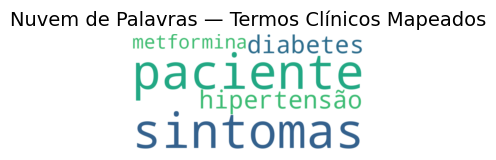

In [8]:
# ==========================================================
# ETAPA 5 — GERAÇÃO DE WORDCLOUD (NUVEM DE PALAVRAS)
# ==========================================================

def gerar_wordcloud(termos_mapeados):
    """
    Gera uma nuvem de palavras (wordcloud) a partir da lista de termos clínicos mapeados.
    """
    texto_unido = " ".join(termos_mapeados)
    wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(texto_unido)

    plt.figure(figsize=(3, 3))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nuvem de Palavras — Termos Clínicos Mapeados", fontsize=14)
    plt.show()


# Exemplo: gerar a nuvem de palavras com base no texto clínico
texto_exemplo = "O paciente apresenta sintomas de hipertensão e diabetes, faz uso de metformina e enalapril."
substantivos = extrair_substantivos(texto_exemplo)
termos_mapeados = [termo for termo in substantivos if buscar_umls_com_distancia(termo) != "Não encontrado na UMLS"]

gerar_wordcloud(termos_mapeados)


# CONCLUSÃO DO PROJETO

#
# Neste projeto, foi possível aplicar técnicas de Processamento de Linguagem Natural (PLN)
# e Explainable AI para analisar textos clínicos, realizando a identificação de entidades médicas
# relevantes e seu mapeamento a conceitos simulados da UMLS.
#
# A inclusão da distância de edição (Levenshtein) demonstrou como o algoritmo
# pode aumentar a robustez do mapeamento, reconhecendo termos mesmo quando
# digitados incorretamente ou com pequenas variações linguísticas.
#
# A WordCloud gerada ao final sintetiza visualmente os principais conceitos
# clínicos detectados, evidenciando a aplicabilidade dessas técnicas em cenários
# de apoio à decisão médica, interoperabilidade de dados em saúde e padronização terminológica.
#
# Este trabalho reforça a importância do PLN como ferramenta fundamental
# para a Inteligência Artificial aplicada à Saúde.
